In [1]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings(action='ignore')

from prophet import Prophet

In [27]:
csv_files = glob.glob('./*.csv')

dataframes = []

for file in csv_files:
    df = pd.read_csv(file, encoding='cp949')
    dataframes.append(df)

combined_dataframe = pd.concat(dataframes, axis=0)

combined_dataframe.head()

,모델번호,시리얼,측정시간,지역,자치구,행정동,방문자수,등록일,기관 명,모델명,서버타입,사이트명,날짜,등록일자,Unnamed: 0,ds,yhat
0,SDOT001,4061.0,2023-05-14_23:55:00,parks,Seoul_Grand_Park,women_parking2,0,2023-05-15 00:08:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,SDOT001,4047.0,2023-05-14_23:56:00,traditional_markets,Gwangjin-gu,Hwayang-dong,56,2023-05-15 00:08:01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,SDOT001,4063.0,2023-05-14_23:57:00,parks,Seoul_Grand_Park,valet_parking2,0,2023-05-15 00:08:01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,SDOT001,4015.0,2023-05-14_23:50:00,main_street,Jung-gu,Gwanghui-dong,138,2023-05-15 00:08:01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,SDOT001,4064.0,2023-05-14_23:57:00,parks,Seoul_Grand_Park,skylift,0,2023-05-15 00:08:01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
combined_dataframe

,모델번호,시리얼,측정시간,지역,자치구,행정동,방문자수,등록일,기관 명,모델명,서버타입,사이트명,날짜,등록일자
0,SDOT001,4061.0,2023-05-14_23:55:00,parks,Seoul_Grand_Park,women_parking2,0,2023-05-15 00:08:00,NaN,NaN,NaN,NaN,NaN,NaN
1,SDOT001,4047.0,2023-05-14_23:56:00,traditional_markets,Gwangjin-gu,Hwayang-dong,56,2023-05-15 00:08:01,NaN,NaN,NaN,NaN,NaN,NaN
2,SDOT001,4063.0,2023-05-14_23:57:00,parks,Seoul_Grand_Park,valet_parking2,0,2023-05-15 00:08:01,NaN,NaN,NaN,NaN,NaN,NaN
3,SDOT001,4015.0,2023-05-14_23:50:00,main_street,Jung-gu,Gwanghui-dong,138,2023-05-15 00:08:01,NaN,NaN,NaN,NaN,NaN,NaN
4,SDOT001,4064.0,2023-05-14_23:57:00,parks,Seoul_Grand_Park,skylift,0,2023-05-15 00:08:01,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18641,SDOT001,3024.0,2023-03-10_18:46:00,traditional_markets,Gangdong-gu,Amsa1-dong,374,2023-03-10 18:58:07,NaN,NaN,NaN,NaN,NaN,NaN
18642,SDOT001,4006.0,2023-03-10_18:40:00,parks,Gangdong-gu,Amsa3-dong,8,2023-03-10 18:58:07,NaN,NaN,NaN,NaN,NaN,NaN
18643,SDOT001,3016.0,2023-03-10_18:46:00,traditional_markets,Yangcheon-gu,Sinwol1-dong,323,2023-03-10 18:58:09,NaN,NaN,NaN,NaN,NaN,NaN
18644,SDOT001,3026.0,2023-03-10_18:46:00,traditional_markets,Guro-gu,Gu-ro4-dong,264,2023-03-10 18:58:09,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
df = combined_dataframe.copy()

In [29]:
serial = combined_dataframe.copy()

In [30]:
serial = serial[serial['자치구']=='Gangnam-gu']

In [31]:
serial['시리얼'].unique()


ap = serial[serial['행정동']=='Apgujeong-dong']
print( '압구정 : ', ap['시리얼'].unique())
ss = serial[serial['행정동']=='Sinsa-dong']
print( '신사 : ', ss['시리얼'].unique())
dc = serial[serial['행정동']=='Daechi4-dong']
print( '대치 : ', dc['시리얼'].unique())
ys1 = serial[serial['행정동']=='Yeoksam1-dong']
print( '역삼1 : ', ys1['시리얼'].unique())
ys2 = serial[serial['행정동']=='Yeoksam2-dong']
print( '역삼2 : ', ys2['시리얼'].unique())
gp = serial[serial['행정동']=='Gaepo2-dong']
print( '개포 : ', gp['시리얼'].unique())
nh = serial[serial['행정동']=='Nonhyeon1-dong']
print( '논현 : ', nh['시리얼'].unique())


압구정 :  [4013.   nan]
신사 :  [4046.   nan]
대치 :  [4009. 4008.   nan]
역삼1 :  [4010.   nan]
역삼2 :  [3005.]
개포 :  [2998. 3011.]
논현 :  [3020.]


In [32]:
df = df[['측정시간', '지역', '자치구', '행정동', '방문자수']]

In [33]:
df_gn = df[df['자치구']=='Gangnam-gu']
df_sc = df[df['자치구']=='Seocho-gu']

In [11]:
df_sc

,측정시간,지역,자치구,행정동,방문자수
41,2023-05-14_23:52:00,main_street,Seocho-gu,Yangjae1-dong,11
44,2023-05-14_23:56:00,main_street,Seocho-gu,Banpo3-dong,53
47,2023-05-14_23:56:00,main_street,Seocho-gu,Seocho4-dong,24
48,2023-05-14_23:50:00,main_street,Seocho-gu,Seocho3-dong,7
51,2023-05-14_23:52:00,main_street,Seocho-gu,Banpo4-dong,64
...,...,...,...,...,...
18581,2023-03-10_18:26:00,main_street,Seocho-gu,Seocho4-dong,415
18583,2023-03-10_18:20:00,main_street,Seocho-gu,Seocho3-dong,96
18586,2023-03-10_18:22:00,main_street,Seocho-gu,Yangjae1-dong,142
18589,2023-03-10_18:26:00,main_street,Seocho-gu,Banpo3-dong,159


In [25]:
df_gn

,행정동,방문자수,day,time,datetime,weekday,weekday_name
37,Apgujeong-dong,13,2023-05-14,23,2023-05-14 23:00:00,6,Sunday
45,Sinsa-dong,4,2023-05-14,23,2023-05-14 23:00:00,6,Sunday
49,Daechi4-dong,62,2023-05-14,23,2023-05-14 23:00:00,6,Sunday
50,Yeoksam1-dong,56,2023-05-14,23,2023-05-14 23:00:00,6,Sunday
85,Apgujeong-dong,44,2023-05-15,0,2023-05-15 00:00:00,0,Monday
...,...,...,...,...,...,...,...
18585,Gaepo2-dong,439,2023-03-10,18,2023-03-10 18:00:00,4,Friday
18587,Yeoksam2-dong,467,2023-03-10,18,2023-03-10 18:00:00,4,Friday
18593,Yeoksam1-dong,471,2023-03-10,18,2023-03-10 18:00:00,4,Friday
18596,Sinsa-dong,226,2023-03-10,18,2023-03-10 18:00:00,4,Friday


In [34]:
df_gn[['day', 'time_d']] = df_gn['측정시간'].str.split('_', expand=True)

df_gn['time'] = df_gn['time_d'].str.split(':').str[0]

print(df_gn[['day', 'time']])

              day time
37     2023-05-14   23
45     2023-05-14   23
49     2023-05-14   23
50     2023-05-14   23
85     2023-05-15   00
...           ...  ...
18585  2023-03-10   18
18587  2023-03-10   18
18593  2023-03-10   18
18596  2023-03-10   18
18636  2023-03-10   18

[335619 rows x 2 columns]


In [35]:
df_gn['datetime'] = pd.to_datetime(df_gn['day'].astype(str) + ' ' + df_gn['time'].astype(str) + ':00:00')
df_gn

,측정시간,지역,자치구,행정동,방문자수,day,time_d,time,datetime
37,2023-05-14_23:56:00,main_street,Gangnam-gu,Apgujeong-dong,13,2023-05-14,23:56:00,23,2023-05-14 23:00:00
45,2023-05-14_23:50:00,main_street,Gangnam-gu,Sinsa-dong,4,2023-05-14,23:50:00,23,2023-05-14 23:00:00
49,2023-05-14_23:56:00,main_street,Gangnam-gu,Daechi4-dong,62,2023-05-14,23:56:00,23,2023-05-14 23:00:00
50,2023-05-14_23:55:00,main_street,Gangnam-gu,Yeoksam1-dong,56,2023-05-14,23:55:00,23,2023-05-14 23:00:00
85,2023-05-15_00:16:00,main_street,Gangnam-gu,Apgujeong-dong,44,2023-05-15,00:16:00,00,2023-05-15 00:00:00
...,...,...,...,...,...,...,...,...,...
18585,2023-03-10_18:24:00,traditional_markets,Gangnam-gu,Gaepo2-dong,439,2023-03-10,18:24:00,18,2023-03-10 18:00:00
18587,2023-03-10_18:24:00,traditional_markets,Gangnam-gu,Yeoksam2-dong,467,2023-03-10,18:24:00,18,2023-03-10 18:00:00
18593,2023-03-10_18:25:00,main_street,Gangnam-gu,Yeoksam1-dong,471,2023-03-10,18:25:00,18,2023-03-10 18:00:00
18596,2023-03-10_18:20:00,main_street,Gangnam-gu,Sinsa-dong,226,2023-03-10,18:20:00,18,2023-03-10 18:00:00


In [11]:
df_gn.info()

<class 'pandas.core.frame.DataFrame'>
Index: 335619 entries, 37 to 18636
Data columns (total 9 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   측정시간      335619 non-null  object        
 1   지역        335619 non-null  object        
 2   자치구       335619 non-null  object        
 3   행정동       335619 non-null  object        
 4   방문자수      335619 non-null  object        
 5   day       335619 non-null  object        
 6   time_d    335619 non-null  object        
 7   time      335619 non-null  object        
 8   datetime  335619 non-null  datetime64[ns]
dtypes: datetime64[ns](1), object(8)
memory usage: 25.6+ MB


In [36]:
df_gn = df_gn[['행정동', '방문자수', 'day', 'time', 'datetime']]

In [37]:
df_gn['방문자수'] = df_gn['방문자수'].astype('int')
df_gn['time'] = df_gn['time'].astype('int')

In [38]:
df_gn['day'] = pd.to_datetime(df_gn['day'])
df_gn['weekday'] = df_gn['day'].dt.dayofweek
weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_gn['weekday_name'] = df_gn['weekday'].apply(lambda x: weekdays[x])

df_gn

,행정동,방문자수,day,time,datetime,weekday,weekday_name
37,Apgujeong-dong,13,2023-05-14,23,2023-05-14 23:00:00,6,Sunday
45,Sinsa-dong,4,2023-05-14,23,2023-05-14 23:00:00,6,Sunday
49,Daechi4-dong,62,2023-05-14,23,2023-05-14 23:00:00,6,Sunday
50,Yeoksam1-dong,56,2023-05-14,23,2023-05-14 23:00:00,6,Sunday
85,Apgujeong-dong,44,2023-05-15,0,2023-05-15 00:00:00,0,Monday
...,...,...,...,...,...,...,...
18585,Gaepo2-dong,439,2023-03-10,18,2023-03-10 18:00:00,4,Friday
18587,Yeoksam2-dong,467,2023-03-10,18,2023-03-10 18:00:00,4,Friday
18593,Yeoksam1-dong,471,2023-03-10,18,2023-03-10 18:00:00,4,Friday
18596,Sinsa-dong,226,2023-03-10,18,2023-03-10 18:00:00,4,Friday


In [39]:
ap = df_gn[df_gn['행정동']=='Apgujeong-dong']
ss = df_gn[df_gn['행정동']=='Sinsa-dong']
dc = df_gn[df_gn['행정동']=='Daechi4-dong']
snh = df_gn[(df_gn['행정동']=='Yeoksam1-dong') | (df_gn['행정동']=='Nonhyeon1-dong')]
# ys2 = df_gn[df_gn['행정동']=='Yeoksam2-dong']
# gp = df_gn[df_gn['행정동']=='Gaepo2-dong']
# nh = df_gn[df_gn['행정동']=='Nonhyeon1-dong']

In [19]:
# ap : 압구정동/압구정로데오거리 -> cluster 압구정
print(ap.shape)
# ss : 신사동/가로수길 -> cluster 신사
print(ss.shape)
# dc : 대치동/한티역~선릉역 사이, 선릉역 근처 -> cluster 선릉
print(dc.shape)
# ys1 : 역삼1동/역삼역 
print(ys1.shape)
# ys2 : 역삼2동/도곡시장(한티역) -> 폐기
print(ys2.shape)
# gp : 개포동/개포시장(개포동역) -> 폐기 
print(gp.shape)
# nh : 영동전통시장(논현역) -> cluster 신논현(ㅠ)
print(nh.shape)


(54929, 7)
(55652, 7)
(91075, 7)
(55676, 7)
(18757, 7)
(42679, 7)
(16851, 7)


In [40]:
def weeken(ds):
    date = pd.to_datetime(ds)
    if date.weekday() == 6 or date.weekday() == 5:
        return 1
    else:
        return 0

def make_test_df(region):
    temp = region.groupby('datetime').sum('방문자수')
    temp.reset_index(inplace=True)
    temp = temp[['datetime', '방문자수']]
    temp.columns = ['ds', 'y']
    temp['weeken'] = temp['ds'].apply(weeken)
    return temp
    
    
def how_many_ppl_in(region):
    region['cap'] = 5000
    region['floor'] = 100
    
    m = Prophet(growth='logistic', daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True, changepoint_prior_scale=1)
    
    m.add_country_holidays(country_name='KR')
    m.add_seasonality(name='day', period=24, fourier_order=1)
    m.add_regressor('weeken')

    m.fit(region)

    future = m.make_future_dataframe(periods=2000, freq='H')
    future['weeken'] = future['ds'].apply(weeken)
    future['cap'] = 5000
    future['floor'] = 10
    pred = m.predict(future)
    raw_pred = pred
    pred = pred[['ds', 'yhat']]
    return m, pred, raw_pred

def trend_plot(model, region, final, raw_pred):
    plt.plot(region['ds'], region['y'], linestyle='-', color='b')
    plt.plot(final['ds'], final['yhat'], linestyle='-', color='r')
    plt.legend()
    model.plot_components(raw_pred)

def get_ppl_of(date, region):
    """
    date 형식 : '2024-04-30 01:00:00'
    """
    return region[region['ds'] == date]['yhat']

In [41]:
ap_df = make_test_df(ap)
ap_m, ap_fin, ap_raw = how_many_ppl_in(ap_df)

ss_df = make_test_df(ss)
ss_m, ss_fin, ss_raw = how_many_ppl_in(ss_df)

dc_df = make_test_df(dc)
dc_m, dc_fin, dc_raw = how_many_ppl_in(dc_df)

snh_df = make_test_df(snh)
snh_m, snh_fin, snh_raw = how_many_ppl_in(snh_df)

# ys1_df = make_test_df(ys1)
# ys1_m, ys1_fin, ys1_raw = how_many_ppl_in(ys1_df)

# nh_df = make_test_df(nh)
# nh_m, nh_fin, nh_raw = how_many_ppl_in(nh_df)

17:29:14 - cmdstanpy - INFO - Chain [1] start processing
17:29:17 - cmdstanpy - INFO - Chain [1] done processing
17:30:07 - cmdstanpy - INFO - Chain [1] start processing
17:30:09 - cmdstanpy - INFO - Chain [1] done processing
17:30:55 - cmdstanpy - INFO - Chain [1] start processing
17:30:58 - cmdstanpy - INFO - Chain [1] done processing
17:31:43 - cmdstanpy - INFO - Chain [1] start processing
17:31:48 - cmdstanpy - INFO - Chain [1] done processing


{'whiskers': [<matplotlib.lines.Line2D at 0x35a6d7d90>,
 'caps': [<matplotlib.lines.Line2D at 0x35d379ab0>,
 'boxes': [<matplotlib.lines.Line2D at 0x35a6d55a0>],
 'medians': [<matplotlib.lines.Line2D at 0x35d2f7430>],
 'fliers': [<matplotlib.lines.Line2D at 0x35d2f5cf0>],
 'means': []}

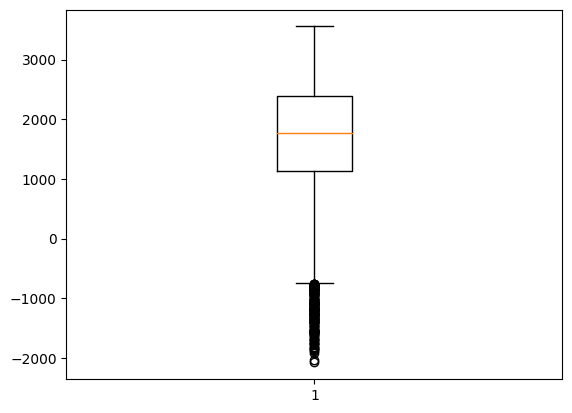

In [156]:
plt.boxplot(nh_fin['yhat'])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


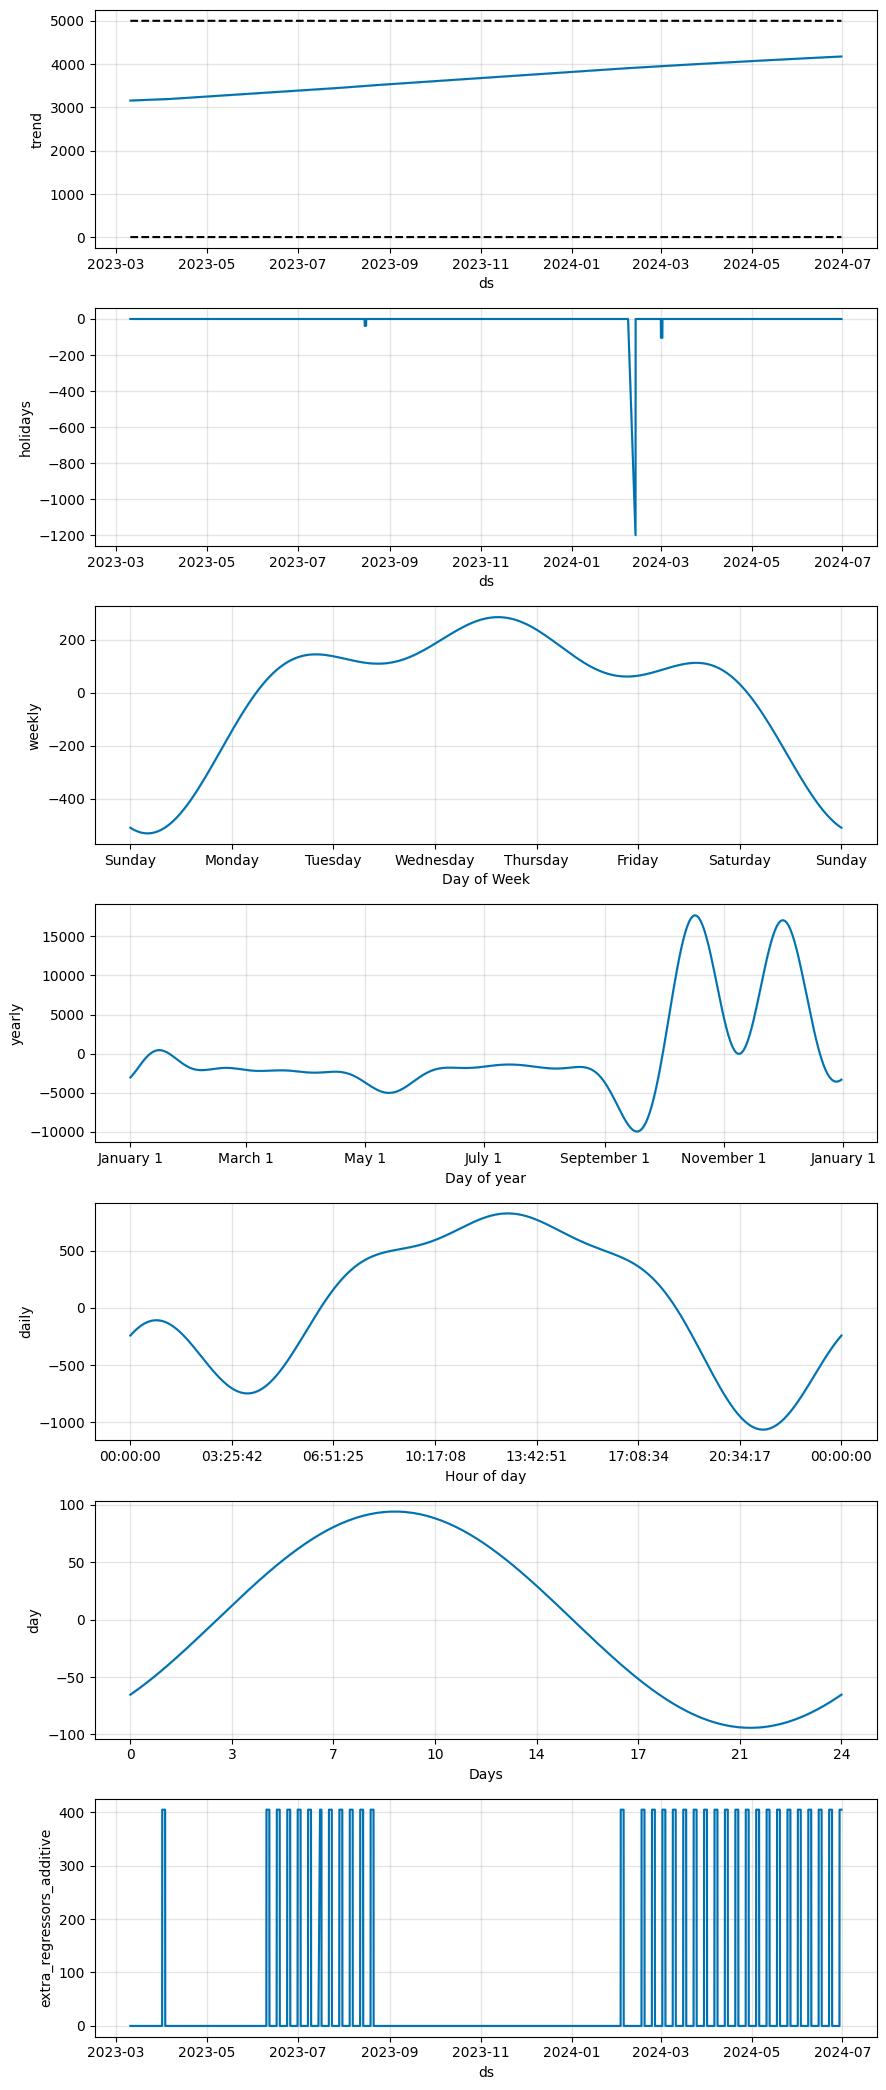

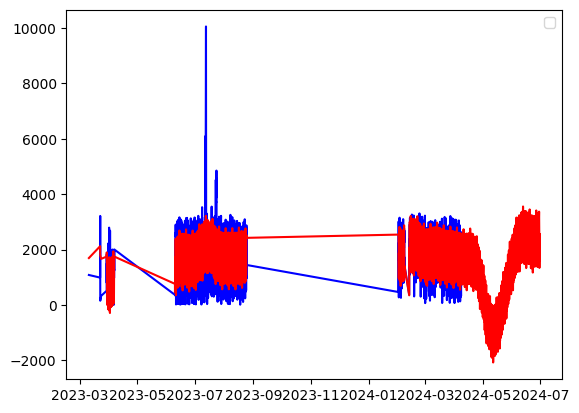

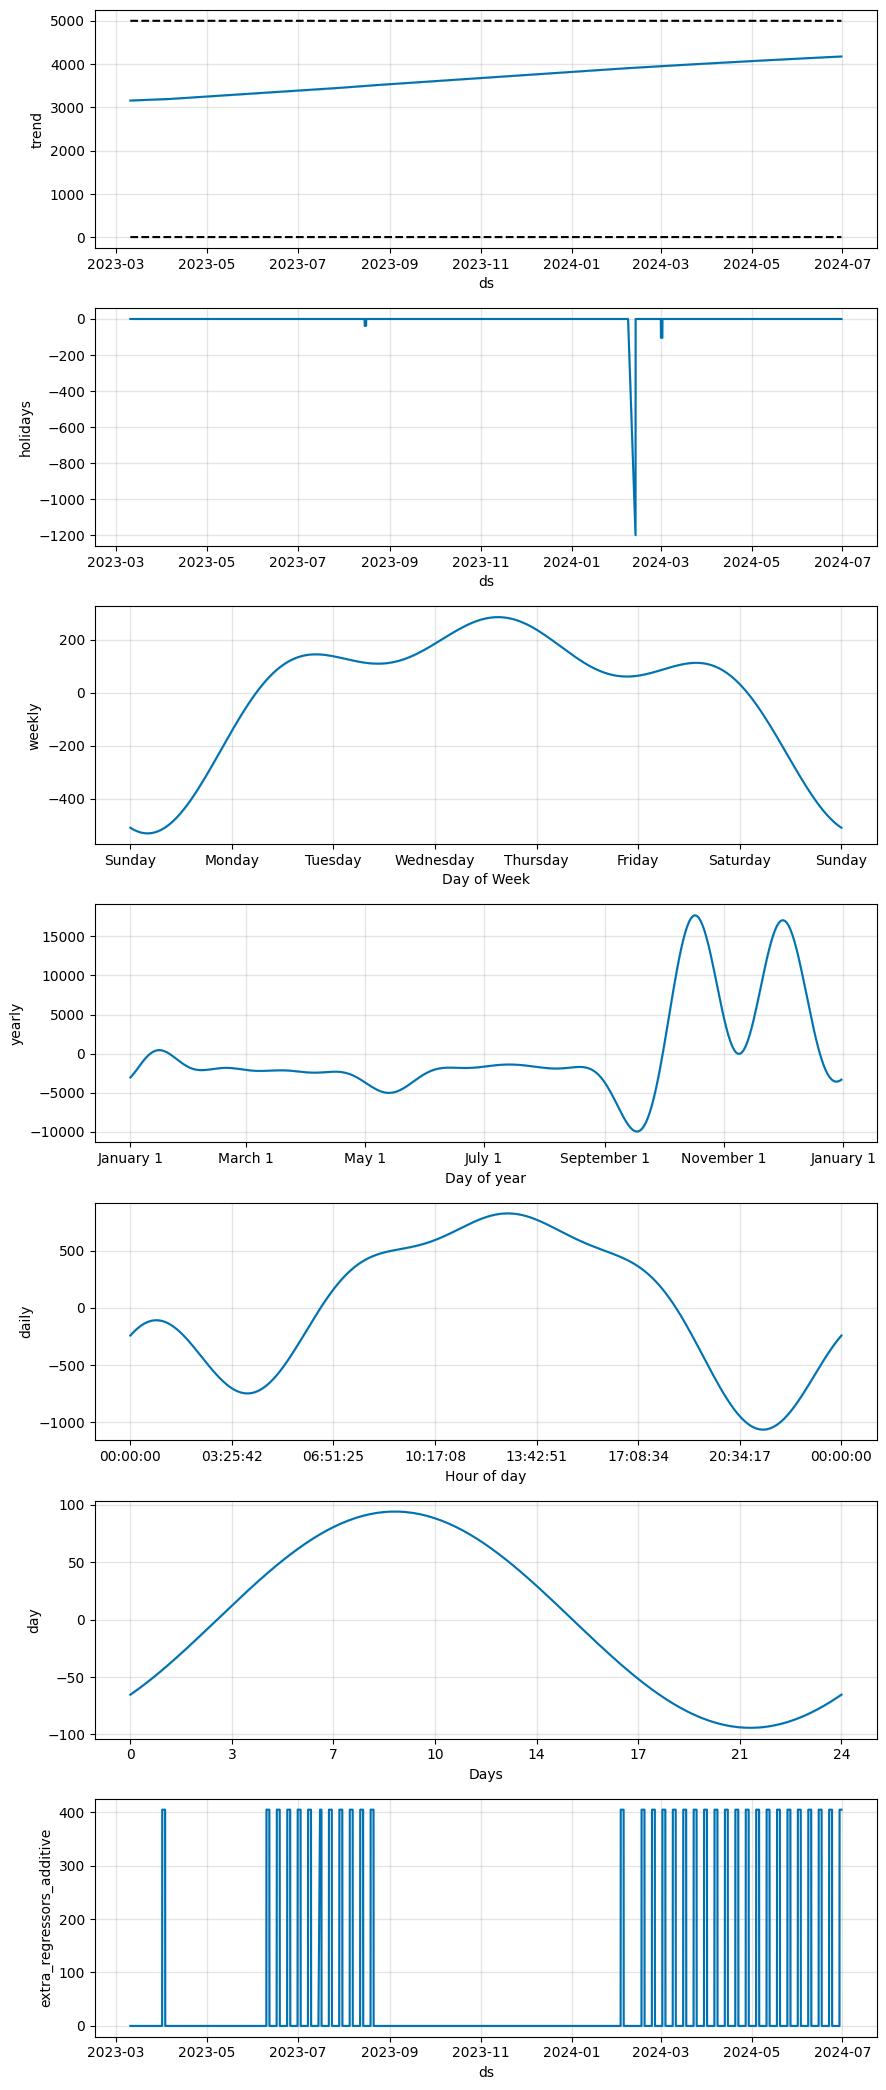

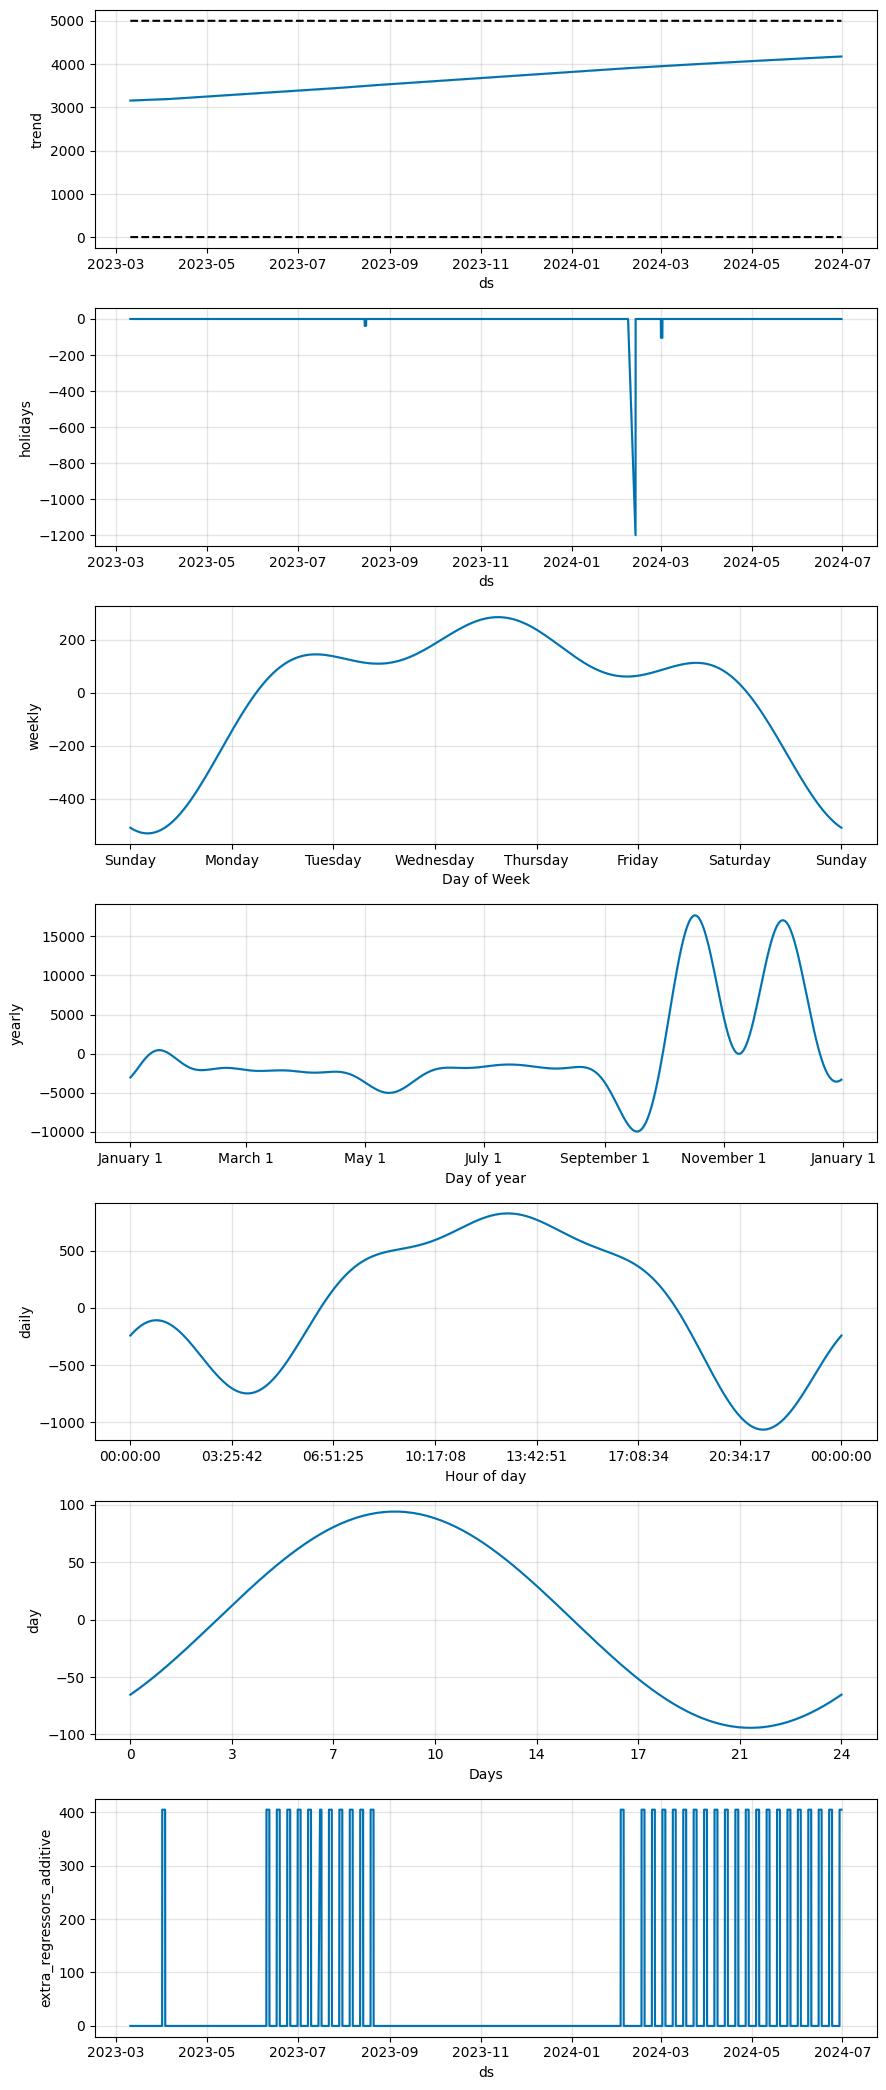

In [157]:
trend_plot(nh_m, nh_df, nh_fin, nh_raw)
nh_m.plot_components(nh_raw)

In [44]:
# ap_fin.to_csv('압구정ppl.csv')
# ss_fin.to_csv('신사ppl.csv')
# dc_fin.to_csv('선릉ppl.csv')
# ys1_fin.to_csv('역삼ppl.csv')
snh_fin.to_csv('신논현ppl.csv')

In [43]:
print(get_ppl_of('2024-05-10 00:00:00', ap_fin)) # 압구정, 청담 
print(get_ppl_of('2024-05-10 00:00:00', ss_fin)) # 신사
print(get_ppl_of('2024-05-10 00:00:00', dc_fin)) # 선릉 
print(get_ppl_of('2024-05-10 00:00:00', snh_fin)) # 신논현

# print(get_ppl_of('2024-05-10 00:00:00', ys1_fin)) # 신논현 
# print(get_ppl_of('2024-05-10 00:00:00', nh_fin)) # 신논현 

11192    48.821723
Name: yhat, dtype: float64
11254    34.855126
Name: yhat, dtype: float64
11279    488.055904
Name: yhat, dtype: float64
11270    1890.407779
Name: yhat, dtype: float64


In [161]:
426.216368+497.748002

923.9643699999999

In [102]:
len(ap['datetime'].unique())

10424

In [103]:
ap_fin = ap.groupby('datetime').sum('방문자수')

In [104]:
ap

,행정동,방문자수,day,time,datetime,weekday,weekday_name
37,Apgujeong-dong,13,2023-05-14,23,2023-05-14 23:00:00,6,Sunday
85,Apgujeong-dong,44,2023-05-15,0,2023-05-15 00:00:00,0,Monday
138,Apgujeong-dong,26,2023-05-15,0,2023-05-15 00:00:00,0,Monday
188,Apgujeong-dong,21,2023-05-15,0,2023-05-15 00:00:00,0,Monday
233,Apgujeong-dong,17,2023-05-15,0,2023-05-15 00:00:00,0,Monday
...,...,...,...,...,...,...,...
18380,Apgujeong-dong,111,2023-03-10,17,2023-03-10 17:00:00,4,Friday
18459,Apgujeong-dong,65,2023-03-10,17,2023-03-10 17:00:00,4,Friday
18472,Apgujeong-dong,121,2023-03-10,18,2023-03-10 18:00:00,4,Friday
18553,Apgujeong-dong,92,2023-03-10,18,2023-03-10 18:00:00,4,Friday


In [105]:
ap_fin = ap.groupby('datetime').sum('방문자수')
ap_fin.reset_index(inplace=True)
ap_fin = ap_fin[['datetime', '방문자수']]
ap_fin.columns = ['ds', 'y']
ap_fin

,ds,y
0,2023-01-01 23:00:00,41
1,2023-01-02 00:00:00,106
2,2023-01-02 01:00:00,113
3,2023-01-02 02:00:00,36
4,2023-01-02 03:00:00,27
...,...,...
10419,2024-04-07 19:00:00,291
10420,2024-04-07 20:00:00,303
10421,2024-04-07 21:00:00,286
10422,2024-04-07 22:00:00,250


In [106]:
def weeken(ds):
    date = pd.to_datetime(ds)
    if date.weekday() == 6 or date.weekday() == 5:
        return 1
    else:
        return 0

ap_fin['weeken'] = ap_fin['ds'].apply(weeken)

In [107]:
ap_fin['cap'] = 5000
ap_fin['floor'] = 10
m = Prophet(growth='logistic', daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True, changepoint_prior_scale=1)
m.add_country_holidays(country_name='KR')
m.add_seasonality(name='day', period=24, fourier_order=1)
m.add_regressor('weeken')

m.fit(ap_fin)

future = m.make_future_dataframe(periods=2000, freq='H')
future['weeken'] = future['ds'].apply(weeken)
future['cap'] = 5000
future['floor'] = 10
pred = m.predict(future)
pred[['ds', 'yhat']]

01:07:47 - cmdstanpy - INFO - Chain [1] start processing
01:07:49 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat
0,2023-01-01 23:00:00,206.323272
1,2023-01-02 00:00:00,241.977413
2,2023-01-02 01:00:00,168.455855
3,2023-01-02 02:00:00,120.007604
4,2023-01-02 03:00:00,95.085033
...,...,...
12419,2024-06-30 03:00:00,372.814348
12420,2024-06-30 04:00:00,354.800929
12421,2024-06-30 05:00:00,335.960396
12422,2024-06-30 06:00:00,318.451239


In [108]:
pred['yhat'].min()

-98.5506508101272

In [109]:
a = pred[['ds','yhat']]
a[a['ds'] == '2024-04-30 01:00:00']['yhat']

10953    57.831073
Name: yhat, dtype: float64

In [110]:
fin = ap_fin.copy()

In [111]:
D = pd.concat([fin, pred[:10256]], axis=1, keys='ds')

In [112]:
D

d                                           s  \
                       ds    y weeken   cap floor                  ds   
0     2023-01-01 23:00:00   41      1  5000    10 2023-01-01 23:00:00   
1     2023-01-02 00:00:00  106      0  5000    10 2023-01-02 00:00:00   
2     2023-01-02 01:00:00  113      0  5000    10 2023-01-02 01:00:00   
3     2023-01-02 02:00:00   36      0  5000    10 2023-01-02 02:00:00   
4     2023-01-02 03:00:00   27      0  5000    10 2023-01-02 03:00:00   
...                   ...  ...    ...   ...   ...                 ...   
10419 2024-04-07 19:00:00  291      1  5000    10                 NaT   
10420 2024-04-07 20:00:00  303      1  5000    10                 NaT   
10421 2024-04-07 21:00:00  286      1  5000    10                 NaT   
10422 2024-04-07 22:00:00  250      1  5000    10                 NaT   
10423 2024-04-07 23:00:00  100      1  5000    10                 NaT   

                                             ...                          \
            trend     cap floor  yhat_lower  ...     weekly weekly_lower   
0      324.692980  5000.0  10.0   63.581873  ... -35.757230   -35.757230   
1      324.702378  5000.0  10.0  102.816813  ... -42.983949   -42.983949   
2      324.711777  5000.0  10.0   22.063159  ... -49.621106   -49.621106   
3      324.721176  5000.0  10.0  -21.884384  ... -55.656492   -55.656492   
4      324.730575  5000.0  10.0  -46.477755  ... -61.083821   -61.083821   
...           ...     ...   ...         ...  ...        ...          ...   
10419         NaN     NaN   NaN         NaN  ...        NaN          NaN   
10420         NaN     NaN   NaN         NaN  ...        NaN          NaN   
10421         NaN     NaN   NaN         NaN  ...        NaN          NaN   
10422         NaN     NaN   NaN         NaN  ...        NaN          NaN   
10423         NaN     NaN   NaN         NaN  ...        NaN          NaN   

                                                                              \
      weekly_upper     yearly yearly_lower yearly_upper multiplicative_terms   
0       -35.757230 -17.507984   -17.507984   -17.507984                  0.0   
1       -42.983949 -17.528627   -17.528627   -17.528627                  0.0   
2       -49.621106 -17.549699   -17.549699   -17.549699                  0.0   
3       -55.656492 -17.571202   -17.571202   -17.571202                  0.0   
4       -61.083821 -17.593139   -17.593139   -17.593139                  0.0   
...            ...        ...          ...          ...                  ...   
10419          NaN        NaN          NaN          NaN                  NaN   
10420          NaN        NaN          NaN          NaN                  NaN   
10421          NaN        NaN          NaN          NaN                  NaN   
10422          NaN        NaN          NaN          NaN                  NaN   
10423          NaN        NaN          NaN          NaN                  NaN   

                                                                         
      multiplicative_terms_lower multiplicative_terms_upper        yhat  
0                            0.0                        0.0  206.323272  
1                            0.0                        0.0  241.977413  
2                            0.0                        0.0  168.455855  
3                            0.0                        0.0  120.007604  
4                            0.0                        0.0   95.085033  
...                          ...                        ...         ...  
10419                        NaN                        NaN         NaN  
10420                        NaN                        NaN         NaN  
10421                        NaN                        NaN         NaN  
10422                        NaN                        NaN         NaN  
10423                        NaN                        NaN         NaN  

[10424 rows x 101 columns]

In [113]:
p = pred['yhat']
t = ap_fin['y'][:10256]

a = abs(t - p)
mae = a.mean()
mae

78.87518294183695

In [114]:
import matplotlib.pyplot as plt

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


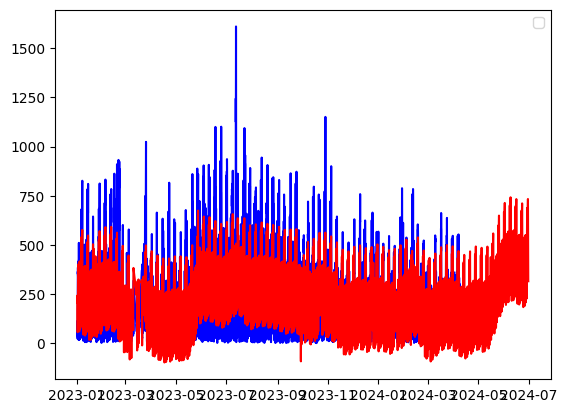

In [115]:
plt.plot(ap_fin['ds'], ap_fin['y'], linestyle='-', color='b')
plt.plot(pred['ds'], pred['yhat'], linestyle='-', color='r')
plt.legend()

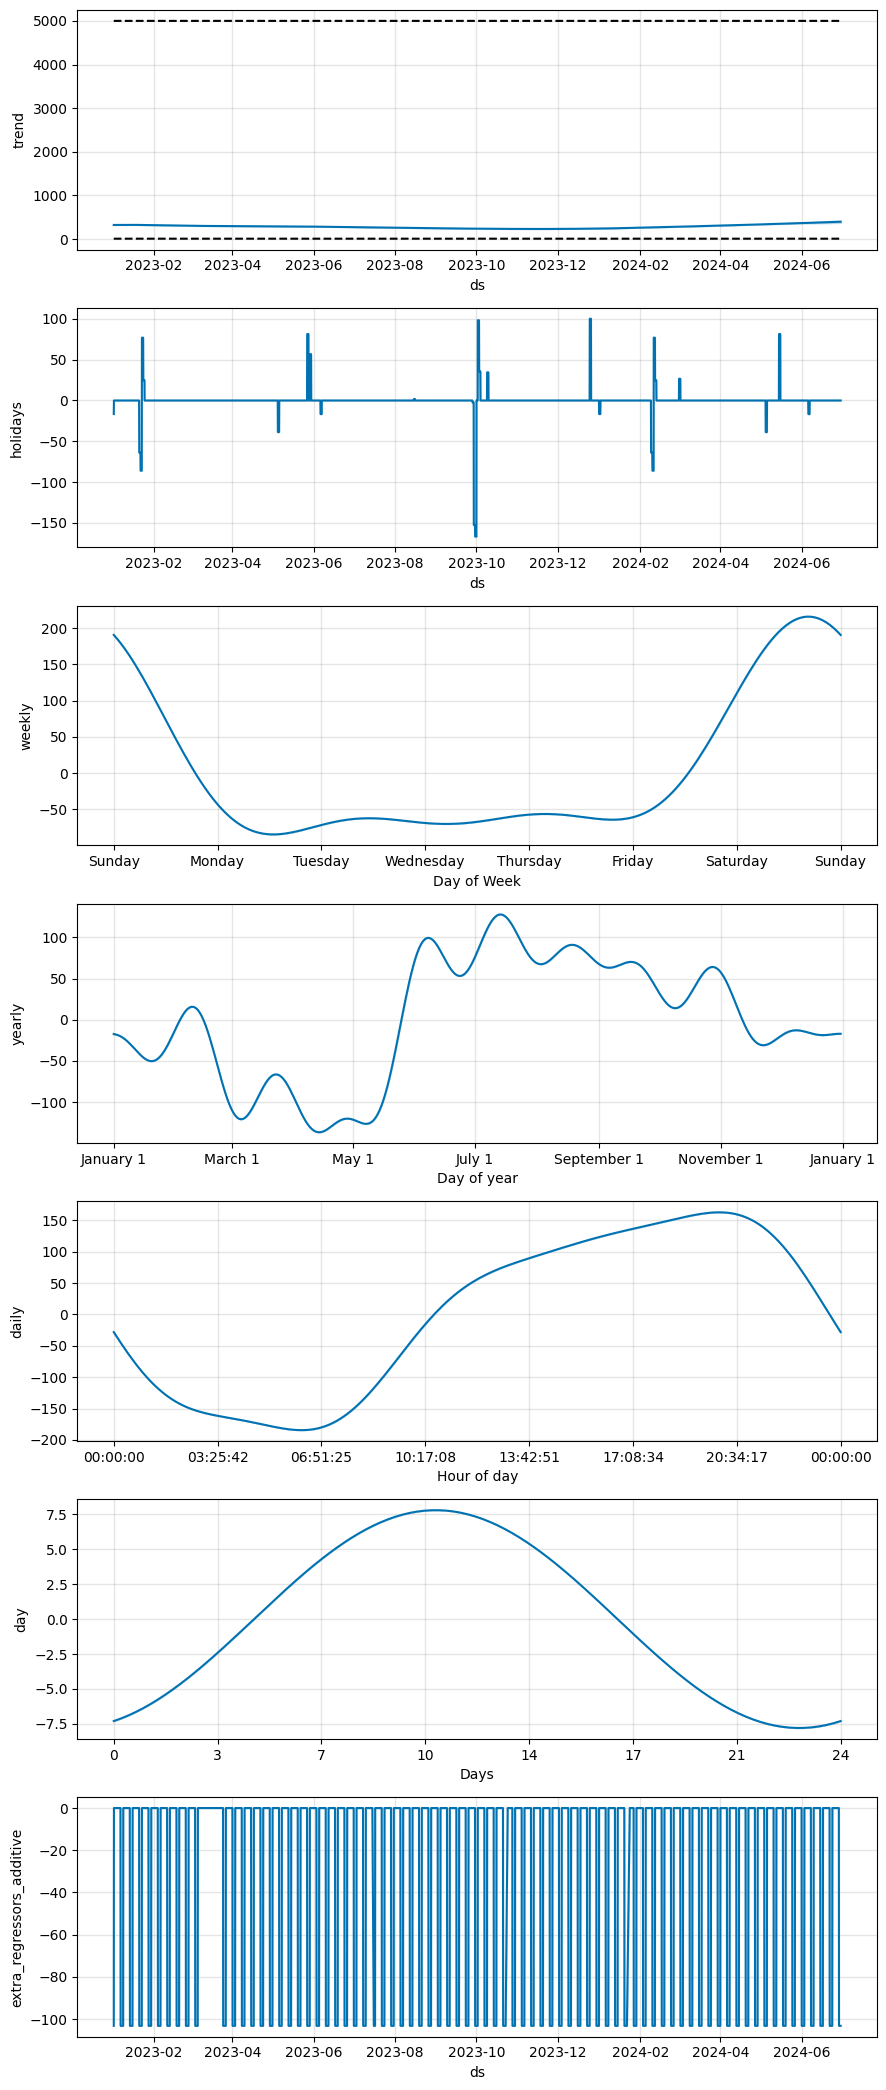

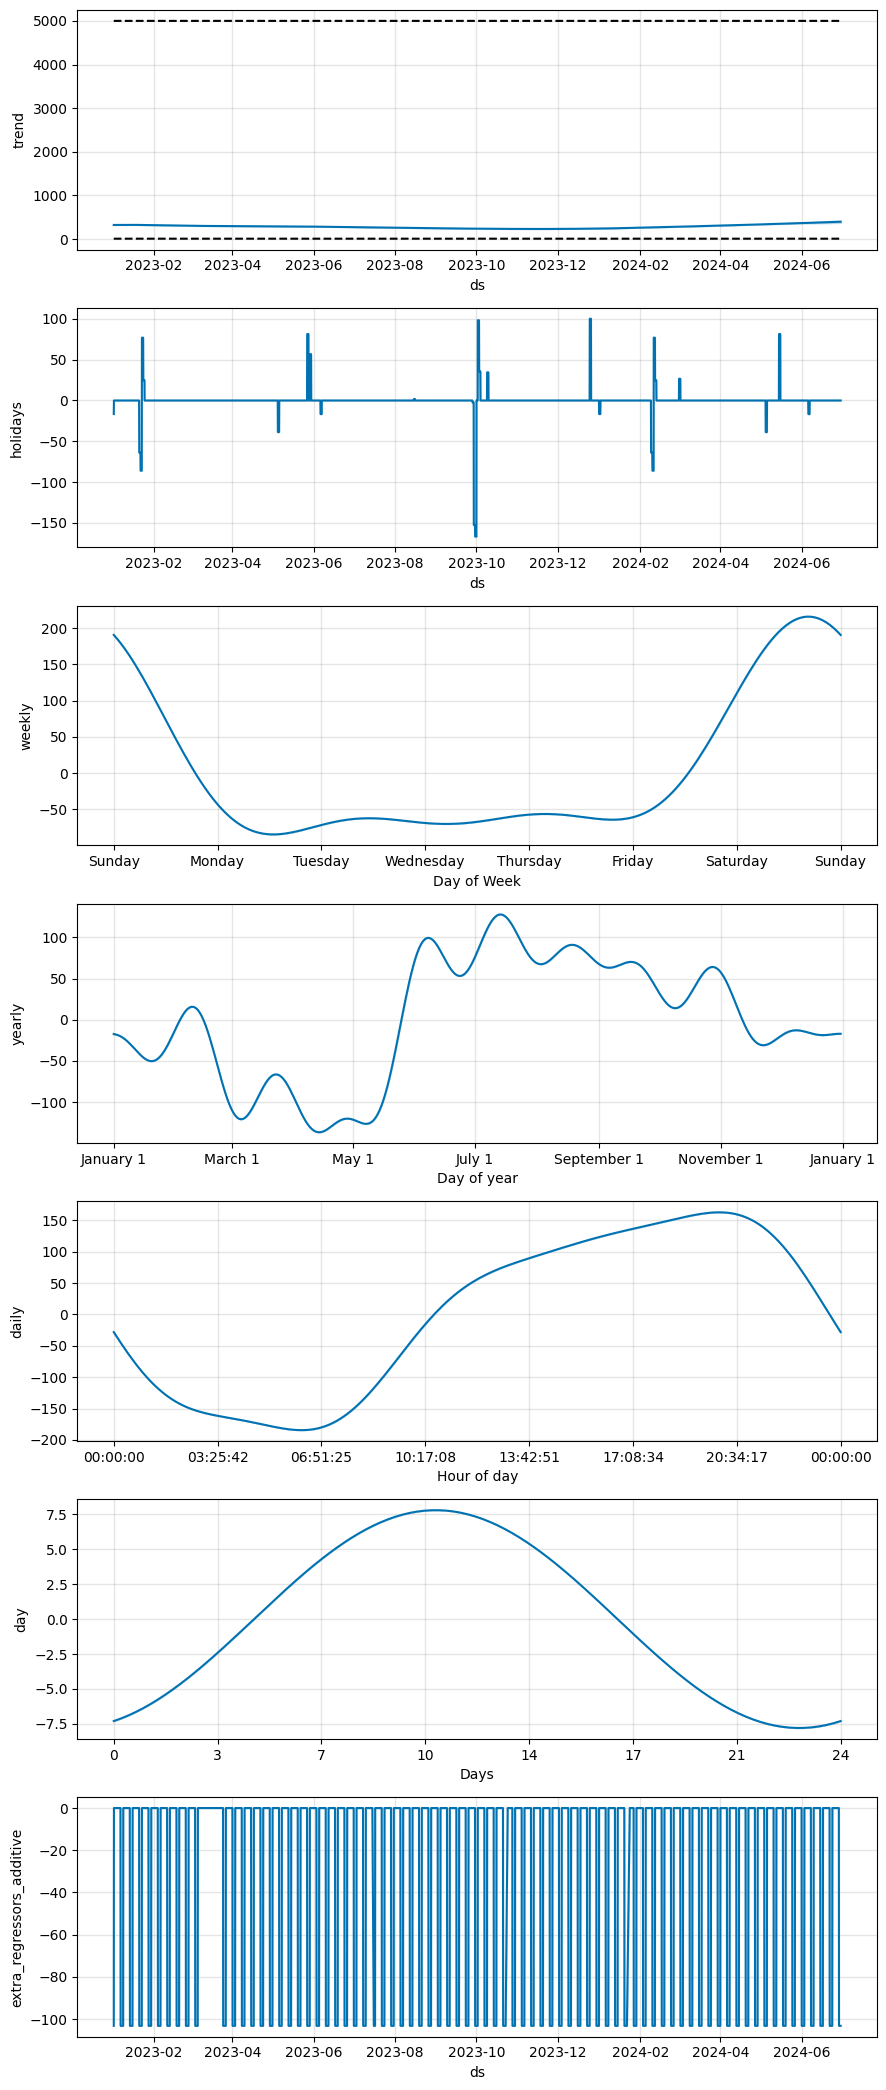

In [116]:
m.plot_components(pred)

In [117]:
ap_fin

,ds,y,weeken,cap,floor
0,2023-01-01 23:00:00,41,1,5000,10
1,2023-01-02 00:00:00,106,0,5000,10
2,2023-01-02 01:00:00,113,0,5000,10
3,2023-01-02 02:00:00,36,0,5000,10
4,2023-01-02 03:00:00,27,0,5000,10
...,...,...,...,...,...
10419,2024-04-07 19:00:00,291,1,5000,10
10420,2024-04-07 20:00:00,303,1,5000,10
10421,2024-04-07 21:00:00,286,1,5000,10
10422,2024-04-07 22:00:00,250,1,5000,10


In [118]:
from tensorflow.keras.layers import Dense, Embedding, LSTM
from tensorflow.keras.models import Sequential

In [119]:
from tensorflow.keras import optimizers


In [120]:
ap_fin

,ds,y,weeken,cap,floor
0,2023-01-01 23:00:00,41,1,5000,10
1,2023-01-02 00:00:00,106,0,5000,10
2,2023-01-02 01:00:00,113,0,5000,10
3,2023-01-02 02:00:00,36,0,5000,10
4,2023-01-02 03:00:00,27,0,5000,10
...,...,...,...,...,...
10419,2024-04-07 19:00:00,291,1,5000,10
10420,2024-04-07 20:00:00,303,1,5000,10
10421,2024-04-07 21:00:00,286,1,5000,10
10422,2024-04-07 22:00:00,250,1,5000,10


In [121]:
ap_lstm = ap.copy()
ap_lstm

,행정동,방문자수,day,time,datetime,weekday,weekday_name
37,Apgujeong-dong,13,2023-05-14,23,2023-05-14 23:00:00,6,Sunday
85,Apgujeong-dong,44,2023-05-15,0,2023-05-15 00:00:00,0,Monday
138,Apgujeong-dong,26,2023-05-15,0,2023-05-15 00:00:00,0,Monday
188,Apgujeong-dong,21,2023-05-15,0,2023-05-15 00:00:00,0,Monday
233,Apgujeong-dong,17,2023-05-15,0,2023-05-15 00:00:00,0,Monday
...,...,...,...,...,...,...,...
18380,Apgujeong-dong,111,2023-03-10,17,2023-03-10 17:00:00,4,Friday
18459,Apgujeong-dong,65,2023-03-10,17,2023-03-10 17:00:00,4,Friday
18472,Apgujeong-dong,121,2023-03-10,18,2023-03-10 18:00:00,4,Friday
18553,Apgujeong-dong,92,2023-03-10,18,2023-03-10 18:00:00,4,Friday


In [122]:
ap_lstm = ap.copy()
ap_lstm = ap_lstm.groupby('datetime').sum('방문자수')
ap_lstm.reset_index(inplace=True)
ap_lstm['weekday'] = ap_lstm['weekday'].apply(lambda x: 0 if x in range(0, 6) else 1)

In [123]:
ap_lstm

,datetime,방문자수,time,weekday
0,2023-01-01 23:00:00,41,23,1
1,2023-01-02 00:00:00,106,0,0
2,2023-01-02 01:00:00,113,6,0
3,2023-01-02 02:00:00,36,4,0
4,2023-01-02 03:00:00,27,6,0
...,...,...,...,...
10419,2024-04-07 19:00:00,291,114,1
10420,2024-04-07 20:00:00,303,120,1
10421,2024-04-07 21:00:00,286,126,1
10422,2024-04-07 22:00:00,250,132,1


In [124]:
ap_lstm_X = ap_lstm.loc[:, ['time', 'weekday']]
ap_lstm_Y = ap_lstm.loc[:, ['방문자수']]

train_X = ap_lstm_X[:8000].values
train_Y = ap_lstm_Y[:8000].values
test_X = ap_lstm_X[8001:].values
test_Y = ap_lstm_Y[8001:].values

In [125]:
model = Sequential() # 초기 입력값 = (batch, 5)
model.add(Dense(units=128, input_dim=2))  # 출력층 = (batch, 128)
model.add(Dense(units=128, input_dim=128))  # 출력층 = (batch, 1)
model.add(Dense(units=128, input_dim=128))  # 출력층 = (batch, 1)
model.add(Dense(units=128, input_dim=128))  # 출력층 = (batch, 1)
model.add(Dense(units=128, input_dim=128))  # 출력층 = (batch, 1)
model.add(Dense(units=1, input_dim=128))  # 출력층 = (batch, 1)

Adam = optimizers.Adam(learning_rate=0.005)

model.summary()
model.compile(optimizer=Adam, loss='mean_absolute_error')
 
model.fit(x=train_X, y=train_Y, batch_size=50, epochs=100)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,561 (260.00 KB)

 Trainable params: 66,561 (260.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 122.8421
Epoch 2/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 104.8013
Epoch 3/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 107.7190
Epoch 4/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 103.7036
Epoch 5/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 941us/step - loss: 103.4438
Epoch 6/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 925us/step - loss: 101.6490
Epoch 7/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 103.2454
Epoch 8/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 960us/step - loss: 103.1096
Epoch 9/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 103.5787 
Epoch 10/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 102.0571
Epoch 11/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 966us/step - loss: 106.7976
Epoch 12/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 102.4189
Epoch 13/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 959us/step - loss: 100.3175
Epoch 14/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 922us/step - loss: 102.0727
Ep

In [126]:
predict_Y = model.predict(x=test_X)
predict_Y = predict_Y.tolist()


# p = pred['yhat']
# t = ap_fin['y'][:10256]

a = abs(test_Y - predict_Y)
mae = a.mean()
mae

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 617us/step


90.6789067481305

In [127]:
model.predict(x=test_X)

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 335us/step


array([[ 38.632103],
       [ 56.561085],
       [ 74.49005 ],
       ...,
       [415.14062 ],
       [433.06973 ],
       [382.27087 ]], dtype=float32)

In [128]:
test_X

array([[  0,   1],
       [  6,   1],
       [ 12,   1],
       ...,
       [126,   1],
       [132,   1],
       [115,   1]])

In [129]:
import requests  # API를 이용해 자료를 받아오기 위해
import pandas as pd 

In [130]:
apikey = '665377766f7a7a7a34346948467364'

In [131]:

url1 = f'http://openapi.seoul.go.kr:8088/{apikey}/json/citydata_ppltn/1/5/선릉역/'

json1 = requests.get(url1).json()


In [132]:
21250/2

10625.0

In [133]:
json1

{'SeoulRtd.citydata_ppltn': [{'AREA_NM': '선릉역',
   'AREA_CD': 'POI034',
   'AREA_CONGEST_LVL': '여유',
   'AREA_CONGEST_MSG': '사람이 몰려있을 가능성이 낮고 붐빔은 거의 느껴지지 않아요. 도보 이동이 자유로워요.',
   'AREA_PPLTN_MIN': '14000',
   'AREA_PPLTN_MAX': '16000',
   'MALE_PPLTN_RATE': '55.4',
   'FEMALE_PPLTN_RATE': '44.6',
   'PPLTN_RATE_0': '0.1',
   'PPLTN_RATE_10': '6.9',
   'PPLTN_RATE_20': '18.5',
   'PPLTN_RATE_30': '25.1',
   'PPLTN_RATE_40': '24.0',
   'PPLTN_RATE_50': '15.1',
   'PPLTN_RATE_60': '6.6',
   'PPLTN_RATE_70': '3.9',
   'RESNT_PPLTN_RATE': '39.4',
   'NON_RESNT_PPLTN_RATE': '60.6',
   'REPLACE_YN': 'N',
   'PPLTN_TIME': '2024-04-30 00:45',
   'FCST_YN': 'Y',
   'FCST_PPLTN': [{'FCST_TIME': '2024-04-30 02:00',
     'FCST_CONGEST_LVL': '여유',
     'FCST_PPLTN_MIN': '14000',
     'FCST_PPLTN_MAX': '16000'},
    {'FCST_TIME': '2024-04-30 03:00',
     'FCST_CONGEST_LVL': '여유',
     'FCST_PPLTN_MIN': '14000',
     'FCST_PPLTN_MAX': '16000'},
    {'FCST_TIME': '2024-04-30 04:00',
     'FCST_CONGEST_L